In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os, sys

sys.path.append(os.path.abspath("../src"))

from pseudorandom_numbers import random
from fixed_point import fpi
from interpolations import interp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]  


## Interpolations

It is often the case that given a set of two-dimensional datapoints of the form $(x, y)$, we want to predict the value of $y$ given some $x$ not present in the dataset.

Imagine our data is defined by the underlying function: 

$$f(x) = \frac{1}{e^{-x} + e^{x}} \quad \text{over the interval} \quad -5 \leq x \leq 5$$

The naive approach is to interpolate our data as a set of piecewise functions over some $N$ sampled points, simply connecting the dots; this just consists of finding 
the linear equation $y = \frac{y_{i+1} - y_{i}}{x_{i + 1} - x_{i}}(x - x_i) + y_i$ and casting it over the interval $[x_i, x_{i+1}]$.

Here is an example of evenly-spaced linear interpolations of our equation:

Average error: 0.0185. Max error: 0.0387


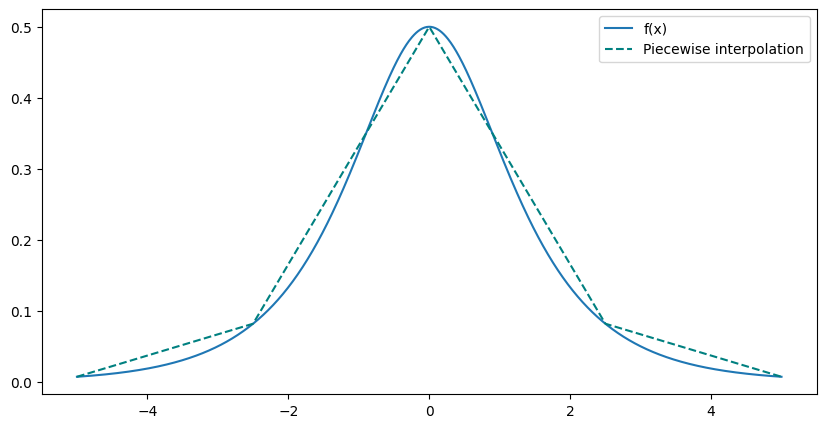

In [11]:
f = lambda x: (
    1 / 
        (np.exp(-x) + np.exp(x)) 
)

# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 5, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

Average error: 0.00965. Max error: 0.0683


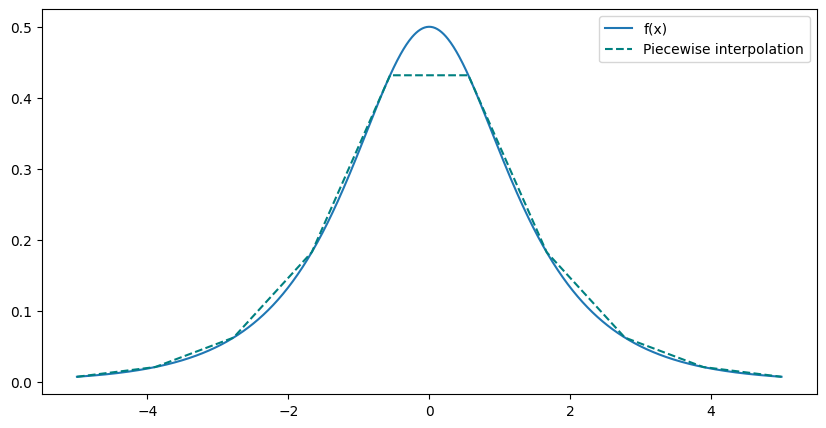

In [12]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 10, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

Average error: 0.00416. Max error: 0.0225


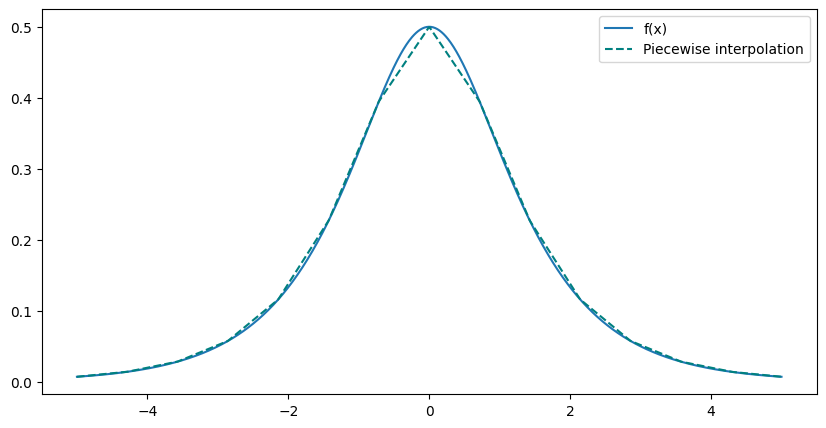

In [13]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 15, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

This is going to be unaccurate for obious reasons. Though the error can only get so high, it will be unaccurate for "swiggly" functions (large magnitude higher-order derivatives), and can actually be computationally expensive for many datapoints.

To acheive smoothness, we can interpolate datapoints into high-order polynomials.

For every set of points $S \subseteq \mathbb{R}^2$, there exists a unqiue function of the oder $|S| - 1$ which passes through every point. The proof isn't needed for the following explanations, but just think of it as: for every data point you add, you need to increase the order of the function by at most one.

One such way to find this unique function is called the Lagrange method. We find our function as:

$$f(x) = y_1L_1 + y_2L_2 + \ldots y_nL_n$$

where $L_i$ is a function that is 1 at $x = x_i$, and $0$ at every other $x_j$. The simplist way to find such a function is by using the form:

$$L_i = \frac{(x - x_1)(x - x_2)\ldots(x - x_{i-1})(x-x_{i + 1})\ldots(x - x_{n-1})(x - x_n)}{(x_i - x_1)(x_i - x_2)\ldots(x_i - x_{i-1})(x_i-x_{i + 1})\ldots(x_i - x_{n-1})(x_i - x_n)}$$

$$L_i = \frac{\prod_{j = 0, \text{ } j \neq i}^{n} (x_i - x_j)}{\prod_{j = 0, \text{ } j \neq i}^{n} (x - x_j)}$$

At any $x = x_j$, one of the terms on top becomes a $0 \rightarrow L_i = 0$; at $x = x_i$, the denominatior equals the numerator, so $L_i = 1$.

In Python, finding our Lagrangian looks like this:

```python
denom = 1
for x_j, _ in points:
    if x_j == x_i:
            continue
        denom *= (x_i - x_j)

    partials = [y_i / denom]

    for root, _ in points:
        if root == x_i:
            continue
        partials = ( # Multiply (x - x_j) against existing partial equation
            [partials[0]] + [partials[i+1] - root*partials[i] for i in range(len(partials)-1)]
            + [-root*partials[-1]]
        )
```
Where partials is the list of coefficients of our lagrangian function in desending order.

This solution is slow, $O(n^2)$, but will ultimatley get us to the unique function $P^{n - 1}(x)$.

We can now use this method to interpolate our inital function:

Average error: 0.0959. Max error: 0.197


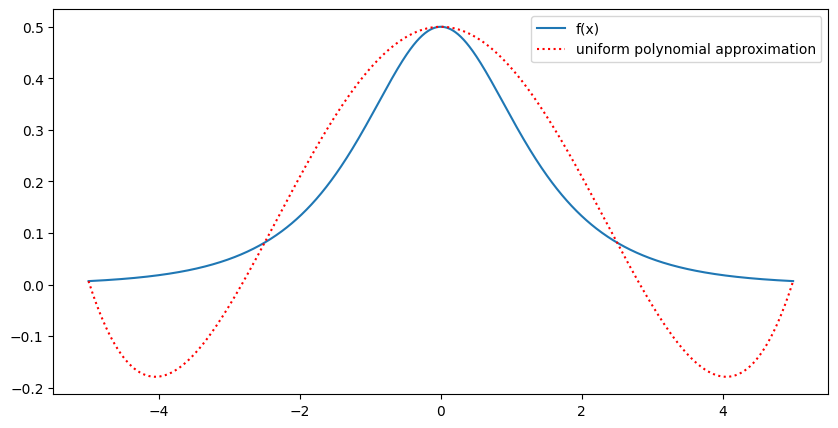

In [14]:
# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 5, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

Average error: 0.0254. Max error: 0.111


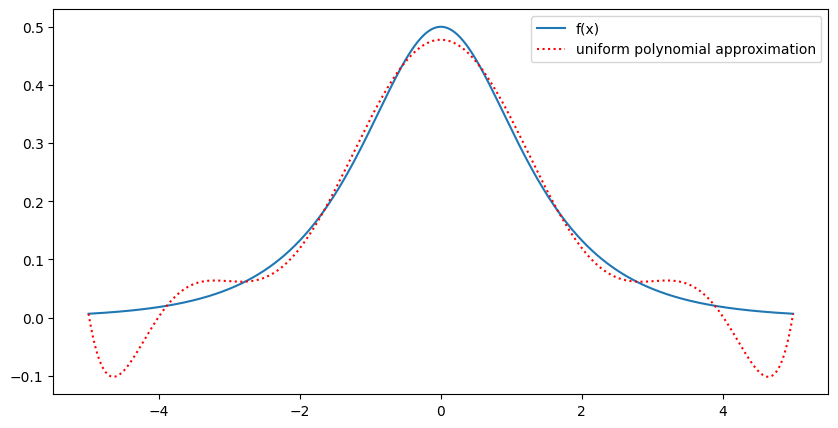

In [15]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 10, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

Average error: 0.0734. Max error: 0.802


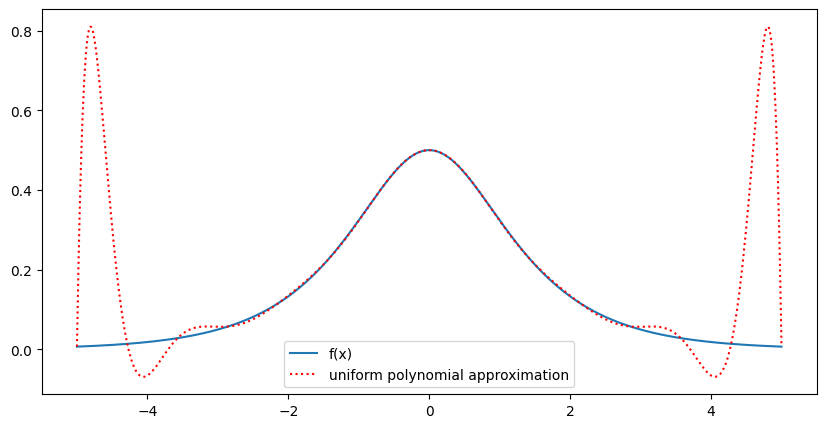

In [16]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 15, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

You can pretty quickly start to see this issue with this approach: using evenly spaced points, our equation will be generally smooth in the middle of our data, but blows up at its endpoints, especially at higher orders.

One solution for this is to cluster our sampled points and the ends using non-uniform distribution. One such distribution that does this is called the Chebyshev distribution, it is defined as follows: 

For $N$ nodes, each $x_i$ can be found as 
$$x_i = \cos\Big(\frac{(2i - 1)\pi}{2N}\Big) \times (b - a) + a$$

This just gets us the cosine distribution over the interval $[-b, a]$ --- the $x$ values of the unit circle as we iterate by equal radians in the first two quadrents for $[-1, 1]$.

Heres a graph of what it looks like: 

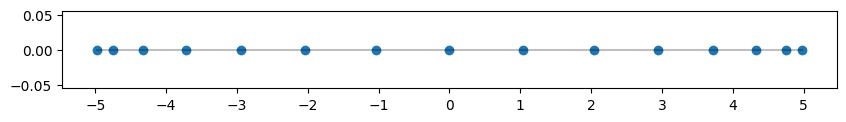

In [17]:
n = 15

points = interp.generate_cheby(lambda x: 0, n, (-5, 5))
cheby_x = [points[i][0] for i in range(n) ]
y = [0] * n

plt.figure(figsize = (10, 1))
plt.plot(cheby_x, y, 'black', alpha = 0.25)
plt.scatter(cheby_x, y, alpha = 1)
plt.xticks(ticks=np.linspace(-5, 5, 11))
plt.show()

You can see this difference in sampling makes a huge impact:

Average error: 0.0712. Max error: 0.14


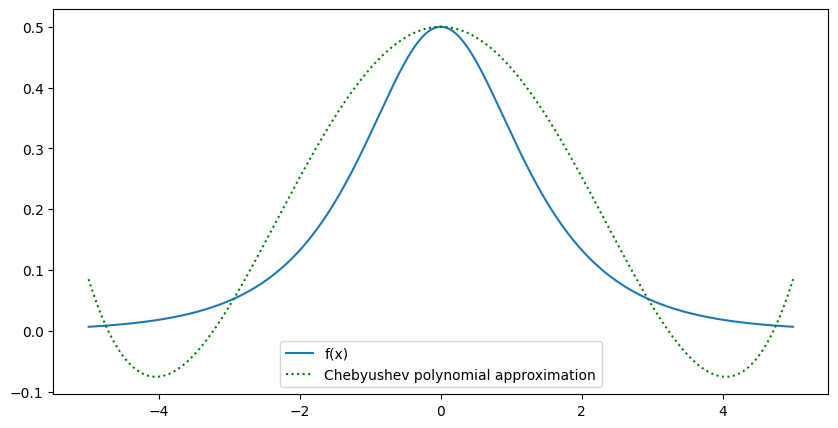

In [18]:
# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 5, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")

Average error: 0.0146. Max error: 0.0576


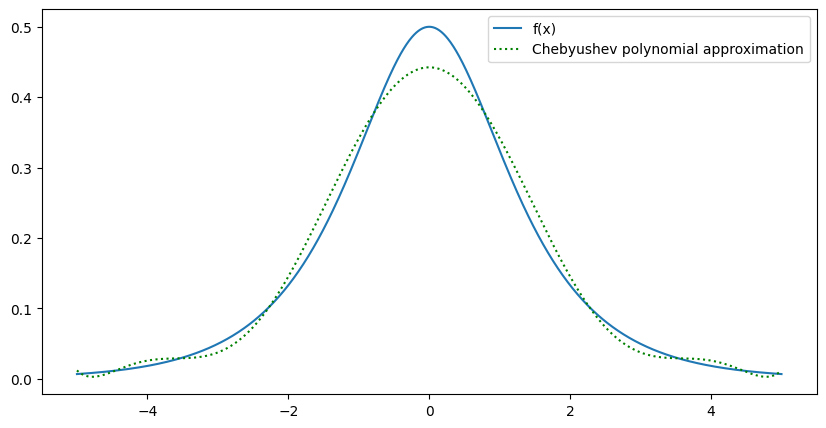

In [19]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 10, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")

Average error: 0.00299. Max error: 0.00616


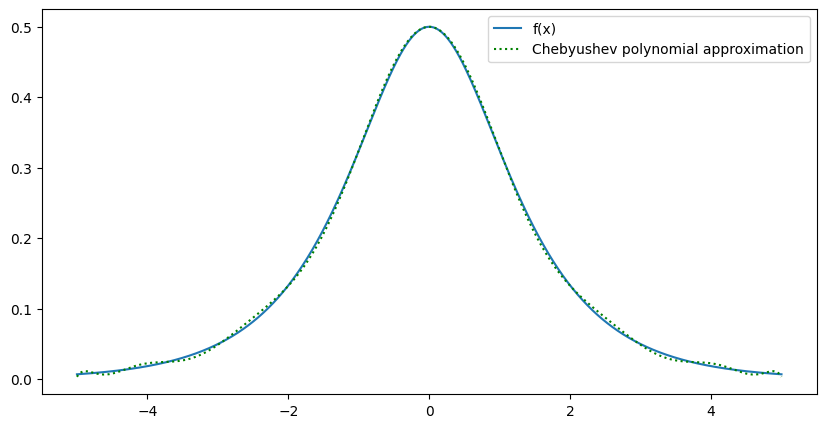

In [26]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 15, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")